# Fake News Detection : Hashing Vectorizer + Multinomial Naive Bayes

This notebook replicates the fake-news classifier using **HashingVectorizer**.

| | CountVectorizer | TF-IDF Vectorizer | HashingVectorizer |
|---|---|---|---|
| Feature value | Raw word count | TF × IDF weight | Hashed word count (signed) |
| Vocabulary stored? | Yes | Yes | **No** - stateless |
| Memory usage | High (large vocab) | High (large vocab) | **Very low** |
| Inverse transform? | Yes | Yes | **No** (lossy hash) |
| Good for large data? | No | No | **Yes** |
| Hash collisions? | N/A | N/A | Rare but possible |

### How HashingVectorizer works
Instead of building a vocabulary dictionary, it applies a **hash function** directly to each word token and maps it to a fixed-size feature vector (default `n_features=2^20 = 1,048,576` columns).  
- No `fit()` step needed, it can transform data without seeing training data first.  
- Trades interpretability for **speed and low memory**, making it ideal for streaming or very large corpora.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import itertools
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn import metrics
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

## 2. Load & Inspect the Dataset

In [2]:
df = pd.read_csv('news.csv', index_col=None)
df

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...,...
6330,4490,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,8062,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,8622,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,4021,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


In [3]:
# Drop the unnamed index column carried over from the CSV
dataset = df.drop("Unnamed: 0", axis=1)
dataset

,title,text,label
0,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL
...,...,...,...
6330,State Department says it can't find emails fro...,The State Department told the Republican Natio...,REAL
6331,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,The ‘P’ in PBS Should Stand for ‘Plutocratic’ ...,FAKE
6332,Anti-Trump Protesters Are Tools of the Oligarc...,Anti-Trump Protesters Are Tools of the Oligar...,FAKE
6333,"In Ethiopia, Obama seeks progress on peace, se...","ADDIS ABABA, Ethiopia —President Obama convene...",REAL


## 3. Define Features & Labels

In [4]:
y = dataset["label"]   # FAKE / REAL

## 4. Train / Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    dataset['text'], y,
    test_size=0.33,
    random_state=53
)

## 5. Hashing Vectorization

### Key parameters explained

| Parameter | Value | Why |
|---|---|---|
| `stop_words` | `'english'` | Same as other notebooks - removes common words |
| `n_features` | `2**18` (262,144) | Fixed output size; larger = fewer collisions |
| `alternate_sign` | `False` | Required for MultinomialNB - keeps all values >= 0 |
| `norm` | `'l2'` | L2-normalises each row (optional, improves stability) |

> **Why `alternate_sign=False`?**  
> By default, HashingVectorizer uses alternating +/- signs to reduce collision bias. But `MultinomialNB` cannot handle negative feature values. Setting `alternate_sign=False` ensures all values are non-negative.

In [6]:
# HashingVectorizer — stateless, no vocabulary is stored
hashing_vectorizer = HashingVectorizer(
    stop_words='english',
    n_features=2**18,       # 262,144 buckets — reduce to 2**16 to save memory
    alternate_sign=False,   # MUST be False for MultinomialNB (needs non-negative values)
    norm='l2'               # L2-normalise each document vector
)

# NOTE: HashingVectorizer is stateless — fit_transform() == transform()
# There is NO vocabulary to learn, so fit() does nothing extra.

hash_train = hashing_vectorizer.fit_transform(X_train)
print("Training matrix shape:", hash_train.shape)
print(hash_train)

Training matrix shape: (4244, 262144)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 1118691 stored elements and shape (4244, 262144)>
  Coords	Values
  (1, 9728)	0.2672612419124244
  (1, 12144)	0.1336306209562122
  (1, 26381)	0.1336306209562122
  (1, 46353)	0.1336306209562122
  (1, 76282)	0.1336306209562122
  (1, 88275)	0.1336306209562122
  (1, 91609)	0.1336306209562122
  (1, 92622)	0.1336306209562122
  (1, 93434)	0.1336306209562122
  (1, 102563)	0.1336306209562122
  (1, 115574)	0.1336306209562122
  (1, 117992)	0.2672612419124244
  (1, 121388)	0.2672612419124244
  (1, 124604)	0.1336306209562122
  (1, 137783)	0.1336306209562122
  (1, 151171)	0.2672612419124244
  (1, 159607)	0.2672612419124244
  (1, 167229)	0.1336306209562122
  (1, 190636)	0.1336306209562122
  (1, 216568)	0.1336306209562122
  (1, 244285)	0.5345224838248488
  (1, 253040)	0.1336306209562122
  (1, 253074)	0.2672612419124244
  (2, 14361)	0.3333333333333333
  (2, 15347)	0.3333333333333333
  :	:
  (4243, 224972

In [7]:
# Transform test data — can even call transform() without fit() for HashingVectorizer
hash_test = hashing_vectorizer.transform(X_test)
print("Test matrix shape:", hash_test.shape)

Test matrix shape: (2091, 262144)


### 5a. Inspect the Hashed Feature Matrix

In [8]:
# Number of non-zero entries in the first document (sparsity check)
first_doc = hash_train[0]
print(f"Non-zero features in first document: {first_doc.nnz} out of {hash_train.shape[1]}")
print(f"Sparsity: {1 - first_doc.nnz / hash_train.shape[1]:.4%}")

Non-zero features in first document: 0 out of 262144
Sparsity: 100.0000%


In [9]:
# Preview dense values for first document (non-zero entries only)
dense_first = first_doc.toarray().flatten()
nonzero_indices = np.nonzero(dense_first)[0]
print("First 10 non-zero (bucket_index, value) pairs for document 0:")
for idx in nonzero_indices[:10]:
    print(f"  bucket {idx:<8} -> {dense_first[idx]:.6f}")

First 10 non-zero (bucket_index, value) pairs for document 0:


> **Note:** Unlike CountVectorizer or TF-IDF, we cannot look up which *word* maps to which bucket index, that information is lost after hashing. This is the trade-off for memory efficiency.

### 5b. Collision Estimate

With `n_features=2**18` and a typical English news vocabulary of approximately 100,000 words, the probability of any two specific words colliding is very low (around 0.04%).

In [10]:
n_features = 2**18
approx_vocab = 100_000   # rough estimate for English news text

# Birthday-problem approximation
collision_prob = 1 - np.exp(-approx_vocab**2 / (2 * n_features))
print(f"n_features       : {n_features:,}")
print(f"Approx vocab size: {approx_vocab:,}")
print(f"Estimated collision probability: {collision_prob:.4%}")
print()
print("Try n_features=2**16 to see how collision probability changes:")
low_feat = 2**16
print(f"  n_features={low_feat:,} -> collision prob: {1 - np.exp(-approx_vocab**2 / (2 * low_feat)):.4%}")

n_features       : 262,144
Approx vocab size: 100,000
Estimated collision probability: 100.0000%

Try n_features=2**16 to see how collision probability changes:
  n_features=65,536 -> collision prob: 100.0000%


## 6. Train Multinomial Naive Bayes

> **Why does this work?** After setting `alternate_sign=False`, all hashed counts are >= 0, satisfying MultinomialNB's non-negativity requirement.

In [11]:
clf = MultinomialNB()
clf.fit(hash_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


## 7. Evaluate on Test Set

In [12]:
pred = clf.predict(hash_test)
score = metrics.accuracy_score(y_test, pred)
print("Accuracy: %0.3f" % score)

cm = metrics.confusion_matrix(y_test, pred, labels=['FAKE', 'REAL'])
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.857

Confusion Matrix:
[[ 745  263]
 [  36 1047]]


In [13]:
report = classification_report(y_test, pred)
print(report)

              precision    recall  f1-score   support

        FAKE       0.95      0.74      0.83      1008
        REAL       0.80      0.97      0.88      1083

    accuracy                           0.86      2091
   macro avg       0.88      0.85      0.85      2091
weighted avg       0.87      0.86      0.85      2091



### 7a. Visualise the Confusion Matrix

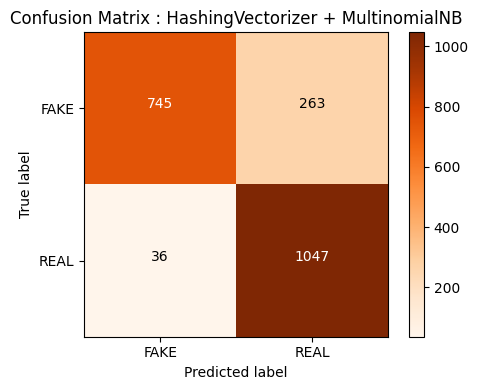

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Oranges)
plt.colorbar(im, ax=ax)

labels = ['FAKE', 'REAL']
tick_marks = np.arange(len(labels))
ax.set_xticks(tick_marks); ax.set_xticklabels(labels)
ax.set_yticks(tick_marks); ax.set_yticklabels(labels)

for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j],
            horizontalalignment='center',
            color='white' if cm[i, j] > cm.max() / 2 else 'black')

ax.set_ylabel('True label')
ax.set_xlabel('Predicted label')
ax.set_title('Confusion Matrix : HashingVectorizer + MultinomialNB')
plt.tight_layout()
plt.show()

## 8. Predict a Single Article

In [16]:
# Inspect the raw text of the first article
print(dataset["text"][0])

Daniel Greenfield, a Shillman Journalism Fellow at the Freedom Center, is a New York writer focusing on radical Islam. 
In the final stretch of the election, Hillary Rodham Clinton has gone to war with the FBI. 
The word “unprecedented” has been thrown around so often this election that it ought to be retired. But it’s still unprecedented for the nominee of a major political party to go war with the FBI. 
But that’s exactly what Hillary and her people have done. Coma patients just waking up now and watching an hour of CNN from their hospital beds would assume that FBI Director James Comey is Hillary’s opponent in this election. 
The FBI is under attack by everyone from Obama to CNN. Hillary’s people have circulated a letter attacking Comey. There are currently more media hit pieces lambasting him than targeting Trump. It wouldn’t be too surprising if the Clintons or their allies were to start running attack ads against the FBI. 
The FBI’s leadership is being warned that the entire left

In [17]:
# View its hashed representation (sparse)
print(hash_train[[0]])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 0 stored elements and shape (1, 262144)>


In [18]:
# Predict the label for the first training article
print("Predicted label:", clf.predict(hash_train[[0]]))

Predicted label: ['FAKE']


In [19]:
# Predict on a completely new, custom sentence
# HashingVectorizer can transform ANY new text immediately — no prior fitting needed
new_article = ["Scientists confirm climate change is accelerating due to greenhouse gases."]
new_hash = hashing_vectorizer.transform(new_article)
print("Custom input prediction:", clf.predict(new_hash))

Custom input prediction: ['REAL']


## 9. All Three Vectorizers : Side-by-Side Comparison

Compare CountVectorizer, TF-IDF, and HashingVectorizer all at once.

In [20]:
import time

results = []

# --- 1. CountVectorizer ---
t0 = time.time()
cv = CountVectorizer(stop_words='english')
cv_train = cv.fit_transform(X_train)
cv_test  = cv.transform(X_test)
clf_cv = MultinomialNB().fit(cv_train, y_train)
acc_cv = metrics.accuracy_score(y_test, clf_cv.predict(cv_test))
t_cv = time.time() - t0
results.append(("CountVectorizer",  acc_cv,  t_cv,  cv_train.shape[1]))

# --- 2. TF-IDF Vectorizer ---
t0 = time.time()
tv = TfidfVectorizer(stop_words='english', sublinear_tf=True)
tv_train = tv.fit_transform(X_train)
tv_test  = tv.transform(X_test)
clf_tv = MultinomialNB().fit(tv_train, y_train)
acc_tv = metrics.accuracy_score(y_test, clf_tv.predict(tv_test))
t_tv = time.time() - t0
results.append(("TF-IDF Vectorizer", acc_tv, t_tv, tv_train.shape[1]))

# --- 3. Hashing Vectorizer ---
t0 = time.time()
hv = HashingVectorizer(stop_words='english', n_features=2**18, alternate_sign=False, norm='l2')
hv_train = hv.fit_transform(X_train)
hv_test  = hv.transform(X_test)
clf_hv = MultinomialNB().fit(hv_train, y_train)
acc_hv = metrics.accuracy_score(y_test, clf_hv.predict(hv_test))
t_hv = time.time() - t0
results.append(("HashingVectorizer", acc_hv, t_hv, 2**18))

print(f"{'Vectorizer':<22} {'Accuracy':>10} {'Time (s)':>10} {'# Features':>12}")
print("-" * 58)
for name, acc, t, feat in results:
    print(f"{name:<22} {acc:>10.3f} {t:>10.3f} {feat:>12,}")

Vectorizer               Accuracy   Time (s)   # Features
----------------------------------------------------------
CountVectorizer             0.893      7.892       56,922
TF-IDF Vectorizer           0.829      7.921       56,922
HashingVectorizer           0.857      7.528      262,144


### 9a. Bar Chart - Accuracy Comparison

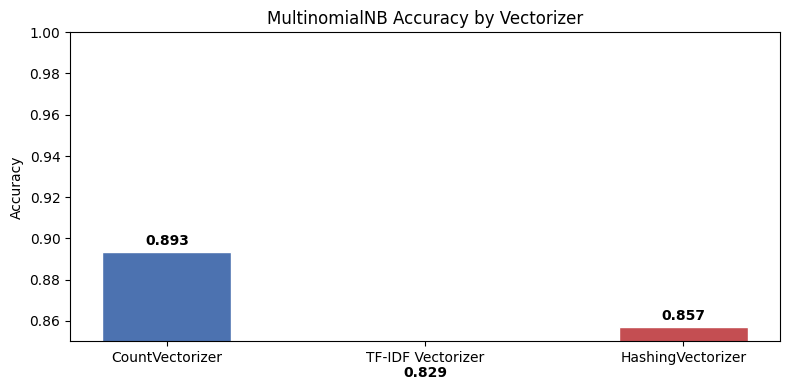

In [21]:
names = [r[0] for r in results]
accs  = [r[1] for r in results]
colors = ['#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(names, accs, color=colors, width=0.5, edgecolor='white')

ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Accuracy')
ax.set_title('MultinomialNB Accuracy by Vectorizer')

for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
            f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 10. Final Interpretation & Summary

### Accuracy Results
- **CountVectorizer** → **0.893** - Best accuracy for this dataset with MultinomialNB
- **HashingVectorizer** → **0.857** - Second place
- **TF-IDF Vectorizer** → **0.829** - Lowest accuracy (poor fit for MultinomialNB)

---

### Speed
- All three vectorizers took nearly the same time - **no significant difference**

---

### Feature Count
| Vectorizer | # Features | Why |
|---|---|---|
| CountVectorizer | 56,922 | Actual vocabulary learned from training data |
| TF-IDF Vectorizer | 56,922 | Same vocabulary, different weighting |
| HashingVectorizer | 262,144 | Fixed bucket size - not real vocabulary |

---

### When to Use Which?
| Vectorizer | Best used when... |
|---|---|
| **CountVectorizer** | Small/medium dataset, need interpretability, using Naive Bayes |
| **TF-IDF Vectorizer** | Using SVM or Logistic Regression, documents have varying lengths |
| **HashingVectorizer** | Very large or streaming data, memory is limited |

---

### Conclusion
> For **Fake News Detection with MultinomialNB**, `CountVectorizer` is the best choice.  
> `TF-IDF` and `HashingVectorizer` are more powerful when paired with models like **Logistic Regression** or **SVM**.